In [ ]:
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

car_sales_path = r"Path_Way"
df = pd.read_csv(car_sales_path)
print(df.head())

                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [5]:
df_filterd = df.sort_values(by = "selling_price")

In [6]:
df_filterd.loc[df_filterd['selling_price'] > 100000, 'selling_price'] = 100000


In [7]:
limit_95 = df['selling_price'].quantile(0.95)
df_filterd = df[df['selling_price'] < limit_95] 

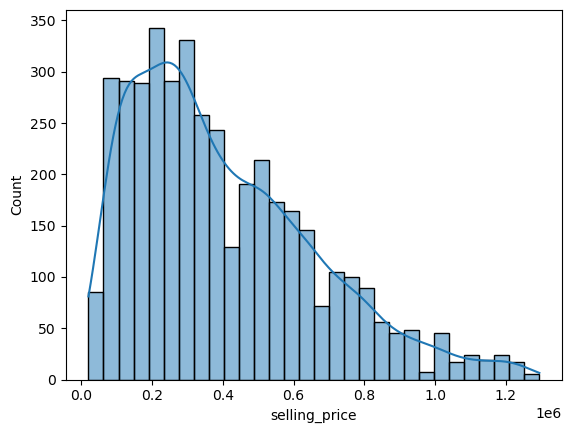

In [8]:
sns.histplot(x='selling_price', data = df_filterd, kde=True)
plt.show()

<Axes: xlabel='transmission', ylabel='selling_price'>

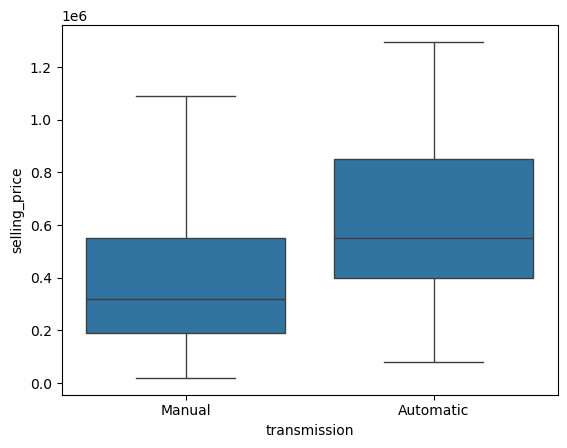

In [9]:
sns.boxplot(data = df_filterd, x='transmission', y='selling_price', showfliers=False)

<Axes: xlabel='km_driven', ylabel='Count'>

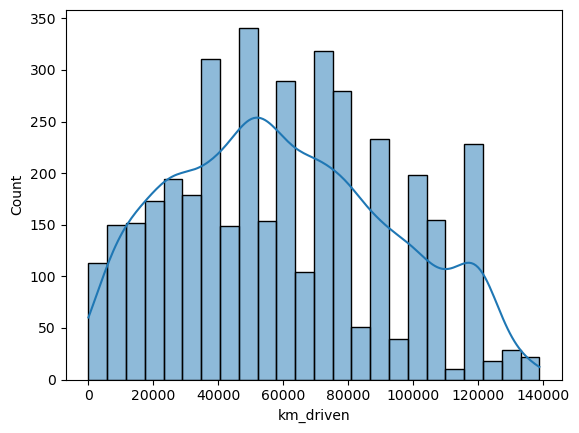

In [10]:
km_limit_95 = df_filterd['km_driven'].quantile(0.95)
df_filterd = df_filterd[df_filterd['km_driven'] < km_limit_95]

sns.histplot(data=df_filterd, x = 'km_driven', kde=True)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'First Owner'),
  Text(1, 0, 'Second Owner'),
  Text(2, 0, 'Fourth & Above Owner'),
  Text(3, 0, 'Third Owner'),
  Text(4, 0, 'Test Drive Car')])

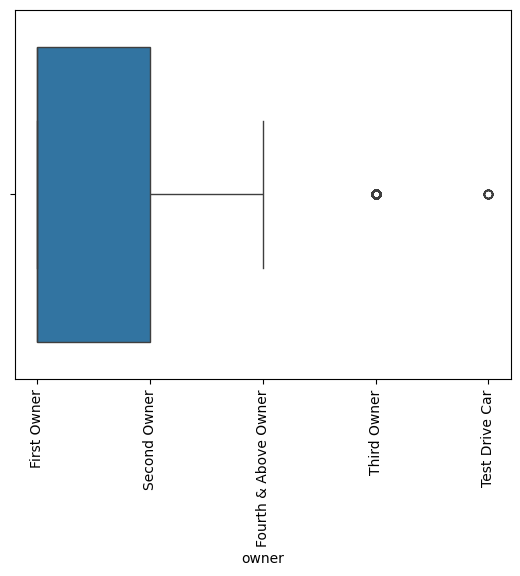

In [11]:
sns.boxplot(data = df_filterd, x='owner')
plt.xticks(rotation = 90)

<Axes: xlabel='seller_type', ylabel='selling_price'>

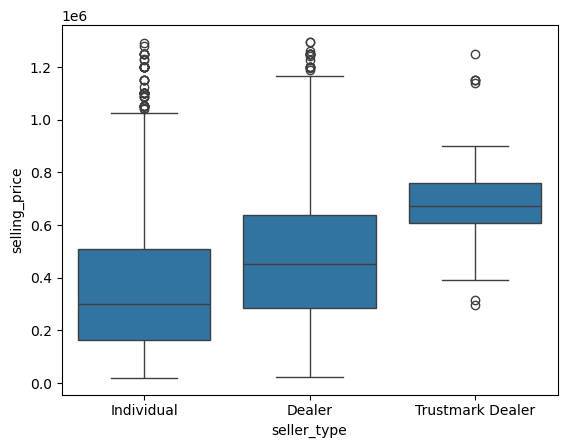

In [12]:
sns.boxplot(data = df_filterd, x='seller_type', y = 'selling_price')

In [13]:
df_filterd.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner


<Axes: xlabel='year', ylabel='selling_price'>

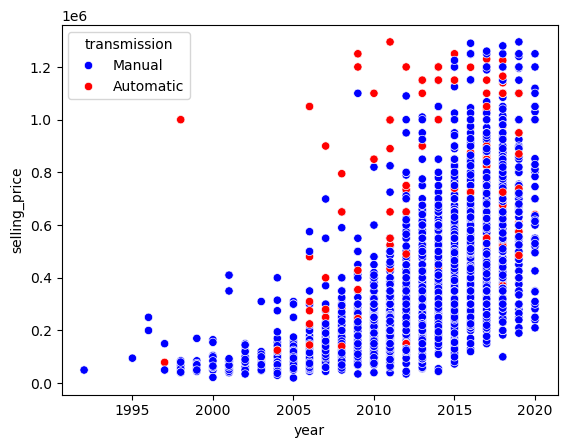

In [14]:
custom = {'Manual': 'blue',
          'Automatic': 'red'}
sns.scatterplot(data = df_filterd, x='year', y='selling_price', hue = 'transmission', palette=custom)

In [15]:
categorical_columns = df_filterd.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f"{col}: {df_filterd[col].nunique()} unique values")

name: 1347 unique values
fuel: 5 unique values
seller_type: 3 unique values
transmission: 2 unique values
owner: 5 unique values


In [16]:
df["brand"] = df['name'].str.split().str[0]

In [17]:
df["brand"].unique()

array(['Maruti', 'Hyundai', 'Datsun', 'Honda', 'Tata', 'Chevrolet',
       'Toyota', 'Jaguar', 'Mercedes-Benz', 'Audi', 'Skoda', 'Jeep',
       'BMW', 'Mahindra', 'Ford', 'Nissan', 'Renault', 'Fiat',
       'Volkswagen', 'Volvo', 'Mitsubishi', 'Land', 'Daewoo', 'MG',
       'Force', 'Isuzu', 'OpelCorsa', 'Ambassador', 'Kia'], dtype=object)

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


car_sales_path = r"Path_Way"
df = pd.read_csv(car_sales_path)
print(df.head())

df["brand"] = df['name'].str.split().str[0]
df["brand"].head()

decending_counts = df["brand"].value_counts().index

                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28],
 [Text(0, 0, 'Land'),
  Text(1, 0, 'BMW'),
  Text(2, 0, 'Mercedes-Benz'),
  Text(3, 0, 'Jaguar'),
  Text(4, 0, 'Volvo'),
  Text(5, 0, 'MG'),
  Text(6, 0, 'Audi'),
  Text(7, 0, 'Isuzu'),
  Text(8, 0, 'Jeep'),
  Text(9, 0, 'Kia'),
  Text(10, 0, 'Mitsubishi'),
  Text(11, 0, 'Toyota'),
  Text(12, 0, 'Mahindra'),
  Text(13, 0, 'Ford'),
  Text(14, 0, 'Honda'),
  Text(15, 0, 'Nissan'),
  Text(16, 0, 'Volkswagen'),
  Text(17, 0, 'Skoda'),
  Text(18, 0, 'Renault'),
  Text(19, 0, 'Hyundai'),
  Text(20, 0, 'Force'),
  Text(21, 0, 'Datsun'),
  Text(22, 0, 'Maruti'),
  Text(23, 0, 'Fiat'),
  Text(24, 0, 'Chevrolet'),
  Text(25, 0, 'Tata'),
  Text(26, 0, 'Ambassador'),
  Text(27, 0, 'OpelCorsa'),
  Text(28, 0, 'Daewoo')])

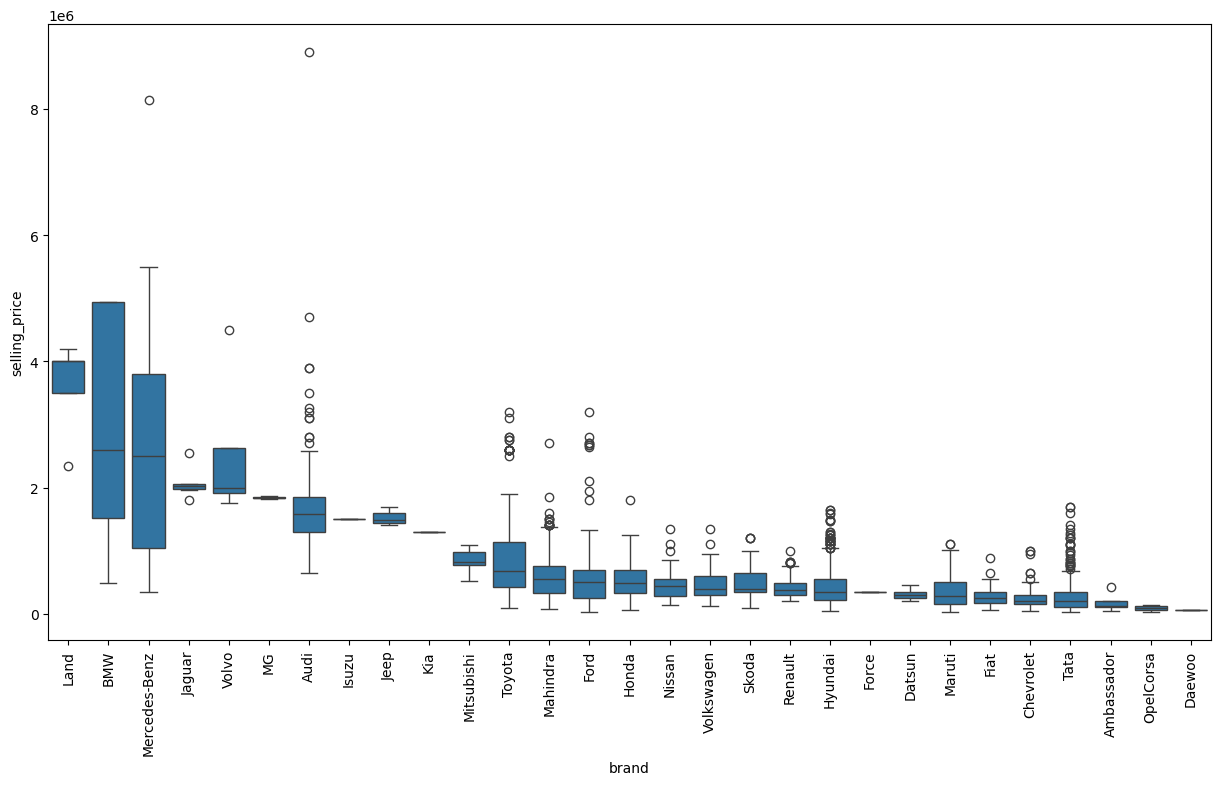

In [19]:
plt.figure(figsize=(15, 8))
sorted_brands = df.groupby('brand')['selling_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='brand', y='selling_price', order=sorted_brands)
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28],
 [Text(0, 0, 'Maruti'),
  Text(1, 0, 'Hyundai'),
  Text(2, 0, 'Mahindra'),
  Text(3, 0, 'Tata'),
  Text(4, 0, 'Honda'),
  Text(5, 0, 'Ford'),
  Text(6, 0, 'Toyota'),
  Text(7, 0, 'Chevrolet'),
  Text(8, 0, 'Renault'),
  Text(9, 0, 'Volkswagen'),
  Text(10, 0, 'Skoda'),
  Text(11, 0, 'Nissan'),
  Text(12, 0, 'Audi'),
  Text(13, 0, 'BMW'),
  Text(14, 0, 'Fiat'),
  Text(15, 0, 'Datsun'),
  Text(16, 0, 'Mercedes-Benz'),
  Text(17, 0, 'Mitsubishi'),
  Text(18, 0, 'Jaguar'),
  Text(19, 0, 'Land'),
  Text(20, 0, 'Ambassador'),
  Text(21, 0, 'Volvo'),
  Text(22, 0, 'Jeep'),
  Text(23, 0, 'OpelCorsa'),
  Text(24, 0, 'MG'),
  Text(25, 0, 'Isuzu'),
  Text(26, 0, 'Force'),
  Text(27, 0, 'Daewoo'),
  Text(28, 0, 'Kia')])

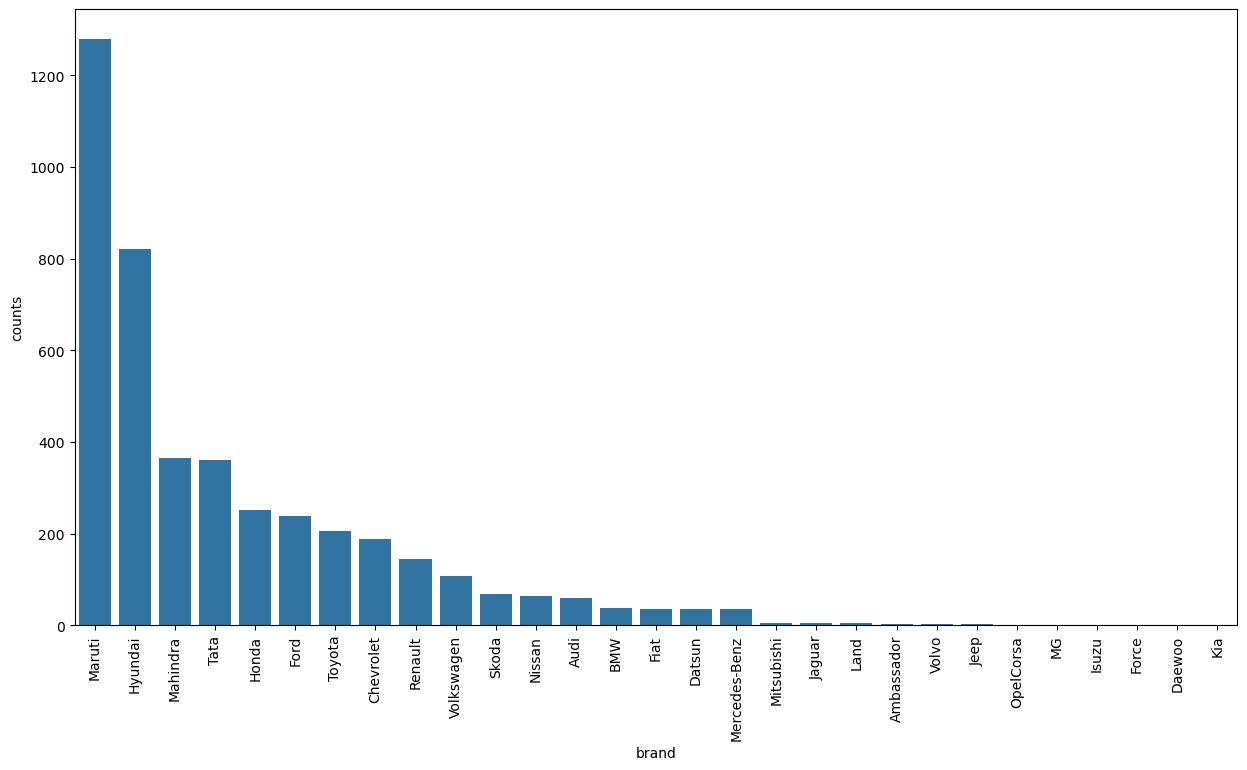

In [20]:
plt.figure(figsize=(15, 8))
counts = df['brand'].value_counts()
df['counts'] = df['brand'].map(counts)
bar_order = df.groupby('brand')['counts'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='brand', y = 'counts', order=bar_order)
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Maruti'),
  Text(1, 0, 'Hyundai'),
  Text(2, 0, 'Mahindra'),
  Text(3, 0, 'Tata'),
  Text(4, 0, 'Honda'),
  Text(5, 0, 'Ford'),
  Text(6, 0, 'Toyota'),
  Text(7, 0, 'Chevrolet'),
  Text(8, 0, 'Renault'),
  Text(9, 0, 'Volkswagen'),
  Text(10, 0, 'Skoda'),
  Text(11, 0, 'Nissan'),
  Text(12, 0, 'Audi'),
  Text(13, 0, 'BMW'),
  Text(14, 0, 'Fiat'),
  Text(15, 0, 'Datsun'),
  Text(16, 0, 'Mercedes-Benz'),
  Text(17, 0, 'Other')])

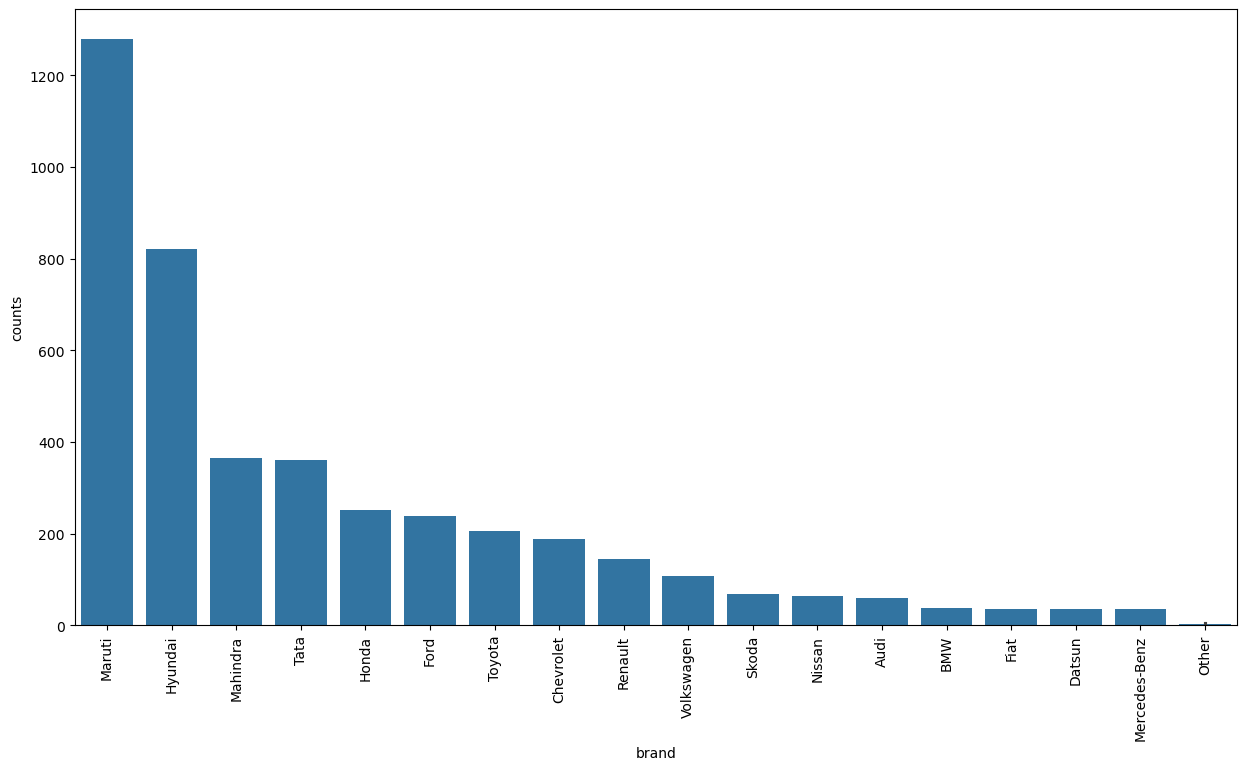

In [21]:
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 10].index
df['brand'] = df['brand'].replace(rare_brands, 'Other')
plt.figure(figsize=(15, 8))
bar_order = df.groupby('brand')['counts'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='brand', y = 'counts', order=bar_order)
plt.xticks(rotation=90)

In [22]:
print(df['brand'].value_counts())

brand
Maruti           1280
Hyundai           821
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            206
Chevrolet         188
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Datsun             37
Fiat               37
Other              36
Mercedes-Benz      35
Name: count, dtype: int64


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
 8   brand          4340 non-null   object
 9   counts         4340 non-null   int64 
dtypes: int64(4), object(6)
memory usage: 339.2+ KB


<Axes: xlabel='fuel', ylabel='selling_price'>

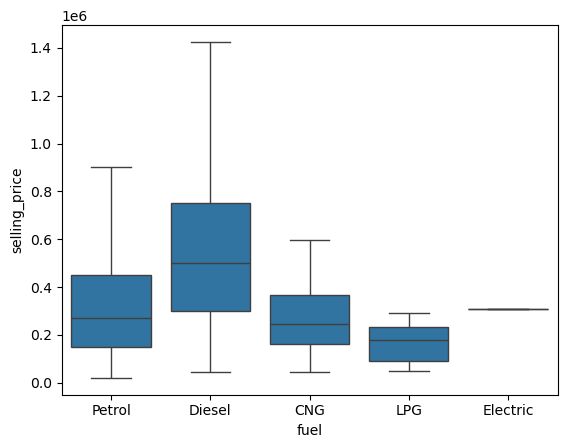

In [24]:
sns.boxplot(data=df, x='fuel', y = 'selling_price', showfliers=False)

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()
df_encoded.shape

(4340, 1522)

In [26]:
df = df.drop('name', axis=1)

In [27]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head

<bound method NDFrame.head of       year  selling_price  km_driven  counts  fuel_Diesel  fuel_Electric  \
0     2007          60000      70000    1280        False          False   
1     2007         135000      50000    1280        False          False   
2     2012         600000     100000     821         True          False   
3     2017         250000      46000      37        False          False   
4     2014         450000     141000     252         True          False   
...    ...            ...        ...     ...          ...            ...   
4335  2014         409999      80000     821         True          False   
4336  2014         409999      80000     821         True          False   
4337  2009         110000      83000    1280        False          False   
4338  2016         865000      90000     821         True          False   
4339  2016         225000      40000     146        False          False   

      fuel_LPG  fuel_Petrol  seller_type_Individual  \
0 

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [30]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
lr_model = LinearRegression().fit(x_train, y_train)
lr_model.score(x_test, y_test)

0.5226497181064789

In [32]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
print("Random Forest: ", rf_model.score(x_test, y_test))

Random Forest:  0.7080185114716895


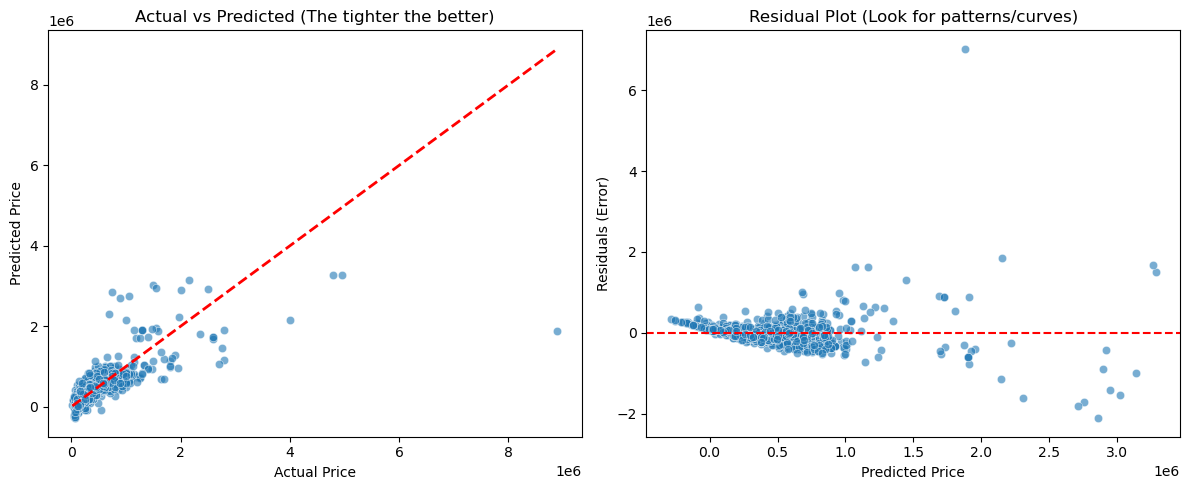

In [33]:
# 1. Generate predictions
y_pred = lr_model.predict(x_test)

# 2. Calculate Residuals (Actual - Predicted)
residuals = y_test - y_pred

# 3. Plotting
plt.figure(figsize=(12, 5))

# Plot A: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted (The tighter the better)')

# Plot B: Residuals
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot (Look for patterns/curves)')

plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year           4340 non-null   int64 
 1   selling_price  4340 non-null   int64 
 2   km_driven      4340 non-null   int64 
 3   fuel           4340 non-null   object
 4   seller_type    4340 non-null   object
 5   transmission   4340 non-null   object
 6   owner          4340 non-null   object
 7   brand          4340 non-null   object
 8   counts         4340 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 305.3+ KB
